# Optical Lab 2 Analysis

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import astropy
import astropy.io.fits as fits
import uwastro465isos
import glob
from uwastro465isos import isochrones
import photutils as ph
import astropy.stats
import astrometry
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder
from photutils.aperture import CircularAperture, aperture_photometry
import astropy.coordinates as astcoo
import astropy.units as u
import astropy.wcs
import warnings
warnings.filterwarnings('ignore')
import keyring
from astroquery.astrometry_net import AstrometryNet
from astropy.wcs import WCS
from astroML.crossmatch import crossmatch_angular
import optical as op

In [8]:
%load_ext autoreload
%autoreload 2

## Demo analysis

In [9]:
!ls obsdata_demo/

bias_02_03        masterflat_g.fits ngc1637_g
g_flat            masterflat_r.fits r_flat
master_bias.fits  ngc1637_b         reduced.fits


In [11]:
!ls obsdata_demo/bias_02_03/

20240204_012528264_Bias.fits 20240204_012751949_Bias.fits
20240204_012542703_Bias.fits 20240204_012806179_Bias.fits
20240204_012557064_Bias.fits 20240204_012820721_Bias.fits
20240204_012611500_Bias.fits 20240204_012834961_Bias.fits
20240204_012625945_Bias.fits 20240204_012849292_Bias.fits
20240204_012640182_Bias.fits 20240204_012903523_Bias.fits
20240204_012654512_Bias.fits 20240204_012918161_Bias.fits
20240204_012708849_Bias.fits 20240204_012932399_Bias.fits
20240204_012723286_Bias.fits 20240204_012946838_Bias.fits
20240204_012737510_Bias.fits


In [13]:
# glob.glob returns a list with all the strings that match the pattern specified
bias_filename_list = glob.glob("obsdata_demo/bias_02_03/*.fits")
bias_filename_list

['obsdata_demo/bias_02_03/20240204_012723286_Bias.fits',
 'obsdata_demo/bias_02_03/20240204_012611500_Bias.fits',
 'obsdata_demo/bias_02_03/20240204_012751949_Bias.fits',
 'obsdata_demo/bias_02_03/20240204_012557064_Bias.fits',
 'obsdata_demo/bias_02_03/20240204_012528264_Bias.fits',
 'obsdata_demo/bias_02_03/20240204_012932399_Bias.fits',
 'obsdata_demo/bias_02_03/20240204_012946838_Bias.fits',
 'obsdata_demo/bias_02_03/20240204_012737510_Bias.fits',
 'obsdata_demo/bias_02_03/20240204_012542703_Bias.fits',
 'obsdata_demo/bias_02_03/20240204_012903523_Bias.fits',
 'obsdata_demo/bias_02_03/20240204_012806179_Bias.fits',
 'obsdata_demo/bias_02_03/20240204_012918161_Bias.fits',
 'obsdata_demo/bias_02_03/20240204_012849292_Bias.fits',
 'obsdata_demo/bias_02_03/20240204_012834961_Bias.fits',
 'obsdata_demo/bias_02_03/20240204_012625945_Bias.fits',
 'obsdata_demo/bias_02_03/20240204_012708849_Bias.fits',
 'obsdata_demo/bias_02_03/20240204_012654512_Bias.fits',
 'obsdata_demo/bias_02_03/20240

In [15]:
bias_stack = []

for filename in bias_filename_list:
    print(filename)
    hdulist = fits.open(filename)
    image = hdulist[0].data.astype(float)
    bias_stack.append(image)

obsdata_demo/bias_02_03/20240204_012723286_Bias.fits
obsdata_demo/bias_02_03/20240204_012611500_Bias.fits
obsdata_demo/bias_02_03/20240204_012751949_Bias.fits
obsdata_demo/bias_02_03/20240204_012557064_Bias.fits
obsdata_demo/bias_02_03/20240204_012528264_Bias.fits
obsdata_demo/bias_02_03/20240204_012932399_Bias.fits
obsdata_demo/bias_02_03/20240204_012946838_Bias.fits
obsdata_demo/bias_02_03/20240204_012737510_Bias.fits
obsdata_demo/bias_02_03/20240204_012542703_Bias.fits
obsdata_demo/bias_02_03/20240204_012903523_Bias.fits
obsdata_demo/bias_02_03/20240204_012806179_Bias.fits
obsdata_demo/bias_02_03/20240204_012918161_Bias.fits
obsdata_demo/bias_02_03/20240204_012849292_Bias.fits
obsdata_demo/bias_02_03/20240204_012834961_Bias.fits
obsdata_demo/bias_02_03/20240204_012625945_Bias.fits
obsdata_demo/bias_02_03/20240204_012708849_Bias.fits
obsdata_demo/bias_02_03/20240204_012654512_Bias.fits
obsdata_demo/bias_02_03/20240204_012820721_Bias.fits
obsdata_demo/bias_02_03/20240204_012640182_Bia

In [16]:
print(len(bias_stack))

19


In [17]:
# (z,x,y) - the way it is printed

bias_stack = np.array(bias_stack)
print(bias_stack.shape)

(19, 2504, 3326)


In [21]:
# because of outliers being the case, using median is a much better choice than mean
master_bias = np.median(bias_stack, axis = 0)
print(master_bias.shape)

(2504, 3326)


In [22]:
# we basically compressed the dimension with 19 values into 1

In [23]:
fits.PrimaryHDU(data = master_bias).writeto("obsdata_demo/master_bias.fits", overwrite = True)

In [24]:
def make_master_flat(glob_string):

    filename_list = glob.glob(glob_string)
    stack = []

    for filename in filename_list:
        print(filename)
        hdulist = fits.open(filename)
        
        # load the image from file
        image = hdulist[0].data.astype(float)
        
        # subtract bias
        image = image - master_bias

        # normalize flat-fields - if you dont, you cannot use the median here
        mean_level = np.mean(image)
        image = image / mean_level
        
        stack.append(image)

    stack = np.array(stack)
    combined = np.median(stack, axis = 0)
    
    return combined

In [29]:
master_flat_g = make_master_flat("obsdata_demo/g_flat/*.fits")
fits.PrimaryHDU(data = master_flat_g).writeto("obsdata_demo/masterflat_g.fits", overwrite = True)

obsdata_demo/g_flat/20240204_014443_Flat_Green.fits
obsdata_demo/g_flat/20240204_014426_Flat_Green.fits
obsdata_demo/g_flat/20240204_014535_Flat_Green.fits
obsdata_demo/g_flat/20240204_014501_Flat_Green.fits
obsdata_demo/g_flat/20240204_014518_Flat_Green.fits


In [30]:
master_flat_r = make_master_flat("obsdata_demo/r_flat/*.fits")
fits.PrimaryHDU(data = master_flat_r).writeto("obsdata_demo/masterflat_r.fits", overwrite = True)

obsdata_demo/r_flat/20240204_014929_Flat_Red.fits
obsdata_demo/r_flat/20240204_014754_Flat_Red.fits
obsdata_demo/r_flat/20240204_014818_Flat_Red.fits
obsdata_demo/r_flat/20240204_014905_Flat_Red.fits
obsdata_demo/r_flat/20240204_014841_Flat_Red.fits


In [32]:
def reduce_image(filename, flatfield):
    hdulist = fits.open(filename)
    image = hdulist[0].data.astype(float)
    
    # subtract bias
    image = image - master_bias
    
    # divide by flat fields
    image = image / flatfield
    
    return image

In [33]:
reduced_image = reduce_image("obsdata_demo/ngc1637_g/20240204_031452_ngc1637-g_Green.fits", master_flat_g)
fits.PrimaryHDU(data = reduced_image).writeto("obsdata_demo/reduced.fits", overwrite = True)

In [37]:
iso = isochrones.Isochrone_Sloan()

/opt/anaconda3/lib/python3.12/site-packages/uwastro465isos/isochrones.py:20: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  self.iso = pandas.read_csv(self.filename, delim_whitespace=True, comment='#', )


In [39]:
# it is the log of ages, not the ages itself - very wide range
iso.get_list_of_ages()

array([ 6.6 ,  6.65,  6.7 ,  6.75,  6.8 ,  6.85,  6.9 ,  6.95,  7.  ,
        7.05,  7.1 ,  7.15,  7.2 ,  7.25,  7.3 ,  7.35,  7.4 ,  7.45,
        7.5 ,  7.55,  7.6 ,  7.65,  7.7 ,  7.75,  7.8 ,  7.85,  7.9 ,
        7.95,  8.  ,  8.05,  8.1 ,  8.15,  8.2 ,  8.25,  8.3 ,  8.35,
        8.4 ,  8.45,  8.5 ,  8.55,  8.6 ,  8.65,  8.7 ,  8.75,  8.8 ,
        8.85,  8.9 ,  8.95,  9.  ,  9.05,  9.1 ,  9.15,  9.2 ,  9.25,
        9.3 ,  9.35,  9.4 ,  9.45,  9.5 ,  9.55,  9.6 ,  9.65,  9.7 ,
        9.75,  9.8 ,  9.85,  9.9 ,  9.95, 10.  , 10.05, 10.1 ])

In [41]:
# measure the iron content relative to the iron content of the sun
# -2 is metal poor
# 0 is equal to the sun's mettalicity
iso.get_list_of_metallicities()

array([-2. , -1.5, -1. , -0.5,  0. ])

In [43]:
# mbolmag - absolute bolomentric magnitude
iso.get_list_of_magnitudes()

['mbolmag', 'umag', 'gmag', 'rmag', 'imag', 'zmag']

In [45]:
iso1 = iso.select_isochrone(log_age = 9.5, metallicity=0)

In [47]:
# isochrones - stars with different masses at the same time during their stellar evolution - which means they will have the same age

(15.0, -5.0)

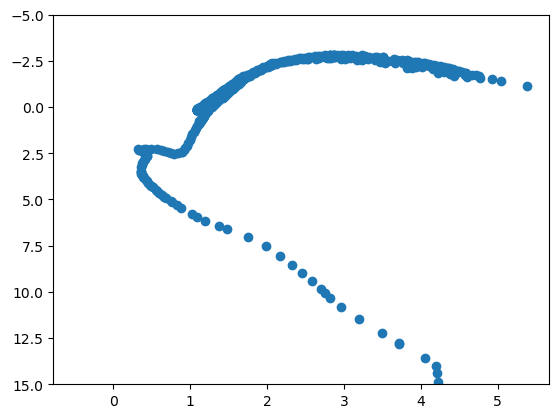

In [49]:
# if you have something that is close to 30, it indicates that the star has already died
fig, ax = plt.subplots()
ax.scatter(iso1['gmag'] - iso1['imag'], iso1['imag'])
# you can invert the axis
ax.set_ylim(15, -5)

(-1.0, 5.0)

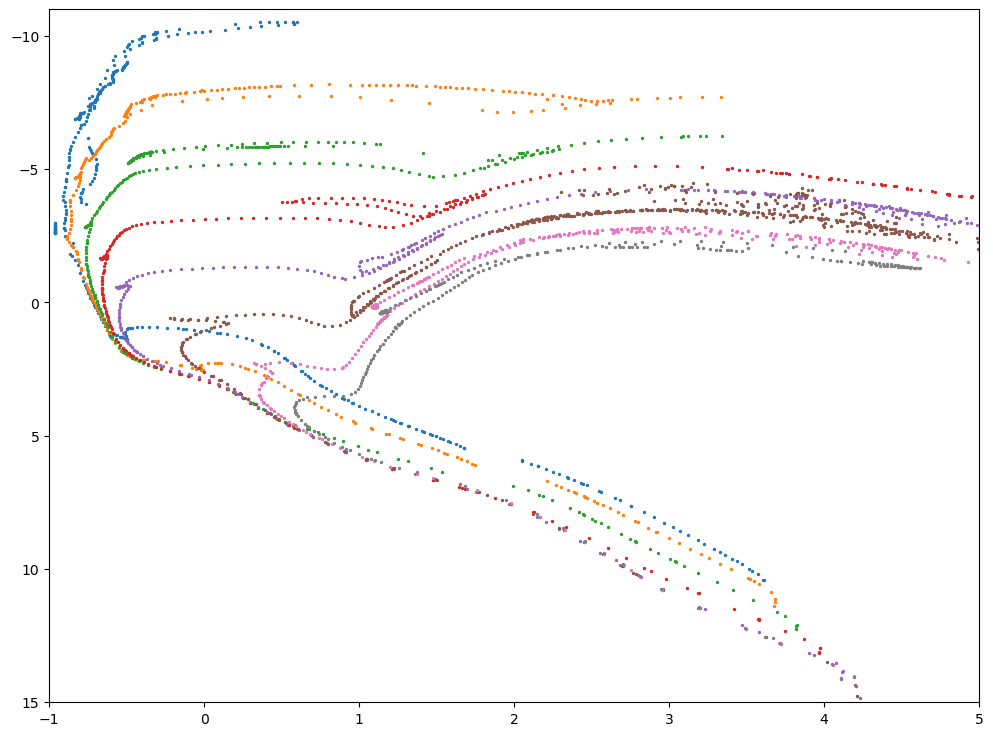

In [51]:
# shape tells you what the age is
# shifting up and down means how far it is from you
# shifting left and right means how much dust is there between you and the cluster
fig, ax = plt.subplots(figsize = (12,9))
for age in [6.6, 7, 7.5, 8, 8.5, 9, 9.5, 10]:
    iso1 = iso.select_isochrone(age, 0)
    ax.scatter(iso1['gmag'] - iso1['imag'], iso1['imag'], s=2)
ax.set_ylim(15, -11)
ax.set_xlim(-1,5)

## Analysis Section for Optical Lab 2

### part 1 - organize your files

In [39]:
!ls

Astronomy_Optical_Lab_2_Report.pdf master_flat_r.png
Lab2_Optical.ipynb                 masterflat_g.fits
__pycache__                        masterflat_i.fits
alex_optical_lab_2.ipynb           masterflat_r.fits
bias_raw.png                       ngc1528
dark                               obsdata_demo
flat_g                             old
flat_i                             optical.py
flat_r                             r_flat_raw.png
flat_z                             reduced_science_g.fits
g_flat_raw.png                     reduced_science_g.png
i_flat_raw.png                     reduced_science_i.fits
master_bias.png                    reduced_science_i.png
master_bias_median.fits            reduced_science_r.fits
master_flat_g.png                  reduced_science_r.png
master_flat_i.png                  science_raw.png


In [41]:
!ls dark/

Dark_20231109_231805.fits Dark_20231109_232453.fits Dark_20231109_233141.fits
Dark_20231109_232129.fits Dark_20231109_232817.fits Dark_20231109_233505.fits


In [43]:
!ls flat_g/

g_flat_g_20231113_063301.fits g_flat_g_20231113_063434.fits
g_flat_g_20231113_063333.fits g_flat_g_20231113_063504.fits
g_flat_g_20231113_063404.fits


In [45]:
!ls flat_i/

i_flat_i_20231113_064446.fits i_flat_i_20231113_064602.fits
i_flat_i_20231113_064510.fits i_flat_i_20231113_064627.fits
i_flat_i_20231113_064536.fits


In [47]:
!ls flat_r/

r_flat_r_20231113_064018.fits r_flat_r_20231113_064145.fits
r_flat_r_20231113_064053.fits r_flat_r_20231113_064210.fits
r_flat_r_20231113_064120.fits


In [49]:
!ls ngc1528/ngc1528_g

wj_NGC1528_g_g_20231113_040800_wcscal.fits
wj_NGC1528_g_g_20231113_040925_wcscal.fits
wj_NGC1528_g_g_20231113_041051_wcscal.fits
wj_NGC1528_g_g_20231113_041216_wcscal.fits
wj_NGC1528_g_g_20231113_041342_wcscal.fits
wj_NGC1528_g_g_20231113_041506_wcscal.fits


In [51]:
!ls ngc1528/ngc1528_i

wj_NGC1528_i_i_20231113_045811_wcscal.fits
wj_NGC1528_i_i_20231113_045935_wcscal.fits
wj_NGC1528_i_i_20231113_050059_wcscal.fits
wj_NGC1528_i_i_20231113_050223_wcscal.fits
wj_NGC1528_i_i_20231113_050346_wcscal.fits
wj_NGC1528_i_i_20231113_050510_wcscal.fits


In [53]:
!ls ngc1528/ngc1528_r

wj_ngc1528_r_r_20231113_042518_wcscal.fits
wj_ngc1528_r_r_20231113_042642_wcscal.fits
wj_ngc1528_r_r_20231113_042809_wcscal.fits
wj_ngc1528_r_r_20231113_042933_wcscal.fits
wj_ngc1528_r_r_20231113_043100_wcscal.fits


### part 2 - Reduce your science images using the calibration products

In [56]:
!ls

Astronomy_Optical_Lab_2_Report.pdf master_flat_r.png
Lab2_Optical.ipynb                 masterflat_g.fits
__pycache__                        masterflat_i.fits
alex_optical_lab_2.ipynb           masterflat_r.fits
bias_raw.png                       ngc1528
dark                               obsdata_demo
flat_g                             old
flat_i                             optical.py
flat_r                             r_flat_raw.png
flat_z                             reduced_science_g.fits
g_flat_raw.png                     reduced_science_g.png
i_flat_raw.png                     reduced_science_i.fits
master_bias.png                    reduced_science_i.png
master_bias_median.fits            reduced_science_r.fits
master_flat_g.png                  reduced_science_r.png
master_flat_i.png                  science_raw.png


In [58]:
master_bias = op.Reduce.make_master_bias("dark/*.fits", mean = False)
master_bias

array([[1324. , 1337.5, 1340.5, ..., 1331.5, 1330. , 1334.5],
       [1332. , 1339.5, 1336.5, ..., 1326.5, 1331.5, 1335. ],
       [1330. , 1337. , 1329.5, ..., 1330.5, 1326. , 1333. ],
       ...,
       [1333.5, 1327.5, 1325. , ..., 1336.5, 1326. , 1332. ],
       [1330. , 1333.5, 1325. , ..., 1334.5, 1332.5, 1326.5],
       [1326. , 1328. , 1335.5, ..., 1329.5, 1331.5, 1328. ]])

In [60]:
master_flat_g = op.Reduce.make_master_flat_field("flat_g/*.fits", master_bias, g = True, i = False)
master_flat_g

array([[0.99741731, 0.96339693, 0.95952227, ..., 0.99888065, 0.99384197,
        0.99775978],
       [0.99650276, 0.95545624, 0.95529892, ..., 0.99711928, 0.99755019,
        0.9917604 ],
       [0.99140201, 0.96674853, 0.96054076, ..., 1.00634198, 0.99112129,
        0.9952518 ],
       ...,
       [1.00834511, 0.99335634, 0.98398313, ..., 1.01287153, 1.01339199,
        1.01601384],
       [1.00776363, 0.99352475, 0.98524794, ..., 1.01956691, 1.00874613,
        1.01672643],
       [1.00910865, 0.98356383, 0.97930536, ..., 1.00002152, 1.01495713,
        1.02094295]])

In [62]:
master_flat_r = op.Reduce.make_master_flat_field("flat_r/*.fits", master_bias, g = False, i = False)
master_flat_r

array([[0.99356255, 0.95418842, 0.9619798 , ..., 0.98219263, 0.99173803,
        0.99139462],
       [0.99326394, 0.95079536, 0.95637448, ..., 0.98488083, 0.98854254,
        0.9894996 ],
       [0.97990158, 0.95788059, 0.95726948, ..., 0.98542695, 0.98099667,
        0.98051757],
       ...,
       [1.0009992 , 0.98149364, 0.98471886, ..., 1.00747031, 0.99920257,
        1.00772566],
       [0.99930523, 0.98702038, 0.9854357 , ..., 0.99802192, 1.00601035,
        0.99925254],
       [0.99152733, 0.98255446, 0.98148054, ..., 0.99907934, 1.00616751,
        0.99855236]])

In [64]:
master_flat_i = op.Reduce.make_master_flat_field("flat_i/*.fits", master_bias, g = False, i = True)
master_flat_i

array([[0.99109272, 0.95316722, 0.95275694, ..., 0.98577504, 0.98977017,
        0.99219917],
       [0.99374769, 0.94788974, 0.94986058, ..., 0.9787894 , 0.9859492 ,
        0.97823037],
       [0.98684862, 0.95227456, 0.95467249, ..., 0.98799843, 0.98073463,
        0.9805124 ],
       ...,
       [0.97991199, 0.96207163, 0.96754574, ..., 0.99346119, 0.98041958,
        0.98927615],
       [0.98040867, 0.96548746, 0.96692013, ..., 0.98699544, 0.98644222,
        0.98047209],
       [0.97894581, 0.96525183, 0.95553744, ..., 0.98083876, 0.988063  ,
        0.98528544]])

In [66]:
# using only one science image to reduce that image and use it for further analysis

In [68]:
# science image for g filter

ngc1528_g = op.Reduce.reduce_science_image("ngc1528/ngc1528_g/wj_NGC1528_g_g_20231113_040800_wcscal.fits", master_bias,master_flat_g)
ngc1528_g
fits.PrimaryHDU(data = ngc1528_g).writeto("reduced_science_g.fits", overwrite = True)

In [70]:
# science image for r filter

ngc1528_r = op.Reduce.reduce_science_image('ngc1528/ngc1528_r/wj_ngc1528_r_r_20231113_042518_wcscal.fits', master_bias,master_flat_r)
ngc1528_r
fits.PrimaryHDU(data = ngc1528_r).writeto("reduced_science_r.fits", overwrite = True)

In [72]:
# science image for i filter

ngc1528_i = op.Reduce.reduce_science_image('ngc1528/ngc1528_i/wj_NGC1528_i_i_20231113_045811_wcscal.fits', master_bias,master_flat_i)
ngc1528_i
fits.PrimaryHDU(data = ngc1528_i).writeto("reduced_science_i.fits", overwrite = True)

In [74]:
background_sub_g, std_g , background_g = op.Extract.estimate_background(ngc1528_g)
background_sub_g

array([[ -7.40399263,  -3.41536647, -16.5509094 , ..., -13.05409634,
          5.02382904, -26.9814996 ],
       [ -3.29978121,  -6.75212375,   5.82567767, ...,  -8.87895902,
          0.10133735,  17.35583083],
       [-10.84253111,   3.98813496, -16.64539138, ...,  -8.77219847,
         14.40827946, -14.22360414],
       ...,
       [  4.91946944,  30.74848526,  27.47461154, ..., -24.20615825,
         34.46571535,  -5.26541841],
       [  4.48712436, -12.55488758, -11.26526874, ...,  -5.12486954,
        -10.98576506, -12.71239564],
       [  6.32226166, -18.22062035,   5.13506613, ...,  15.83963302,
        -24.37353075,  18.7370536 ]])

In [76]:
background_sub_r, std_r, background_r = op.Extract.estimate_background(ngc1528_r)
background_sub_r

array([[ -9.8411024 ,   0.6673064 , -14.6966341 , ...,   5.95872995,
         -2.61799108,   4.9806402 ],
       [-11.82773595,   8.38673298, -16.29131413, ..., -11.58986261,
          8.31661465, -17.55818963],
       [ 15.89995576,  10.19925634, -13.23511915, ...,  -9.60895967,
         -1.55808861,  -4.56988083],
       ...,
       [  0.98193252,  19.2788953 ,  21.42892763, ..., -19.51464889,
         26.68280872, -16.0617278 ],
       [ 11.65942489, -15.83284714,  10.17844462, ..., -28.77801695,
         21.35635738,  39.18585293],
       [ 30.68456576,  -0.69548428,  15.20500347, ..., -19.84448781,
          9.41104953,  -6.28292191]])

In [78]:
background_sub_i, std_i, background_i = op.Extract.estimate_background(ngc1528_i)
background_sub_i

array([[  5.3571387 ,   3.29635534,  17.99574985, ...,   5.94055432,
          3.3553428 , -26.40627171],
       [  2.30052413,   1.25357881,   3.33835601, ...,   0.93718329,
        -10.29006051,  12.69865207],
       [  4.40456237,  -1.41786281,   6.41977087, ...,   7.93174753,
          5.50632944, -16.92768328],
       ...,
       [-12.3404333 , -10.32781942,  -0.50034101, ...,   4.82017097,
          2.45100227, -17.8662448 ],
       [ -2.64878702,  -1.00058719,   5.71027826, ...,  -0.15668873,
         -8.26181189,  13.15952831],
       [  1.44638611,  12.98729664,  -4.05929235, ...,   7.03411725,
         12.99106212,   2.39559346]])

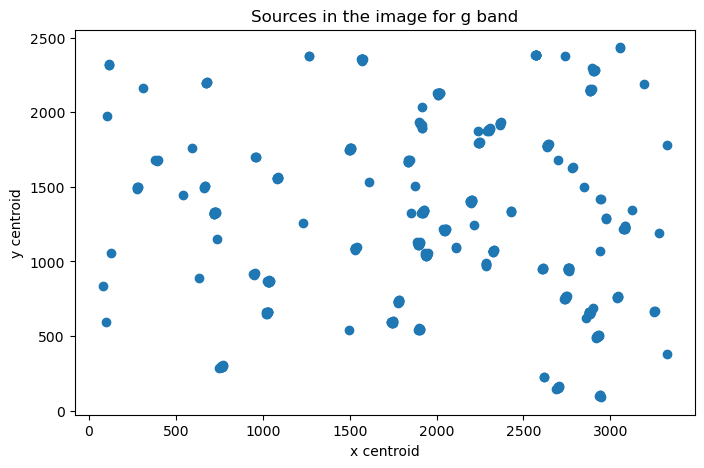

In [290]:
sources_g = op.Extract.detect_source(background_sub_g, std_g, 5.0)
plt.figure(figsize = (8,5))
plt.scatter(sources_g['xcentroid'], sources_g['ycentroid'])
plt.xlabel('x centroid')
plt.ylabel('y centroid')
plt.title("Sources in the image for g band")
plt.savefig("sources_g.png", format = 'png')
plt.show()

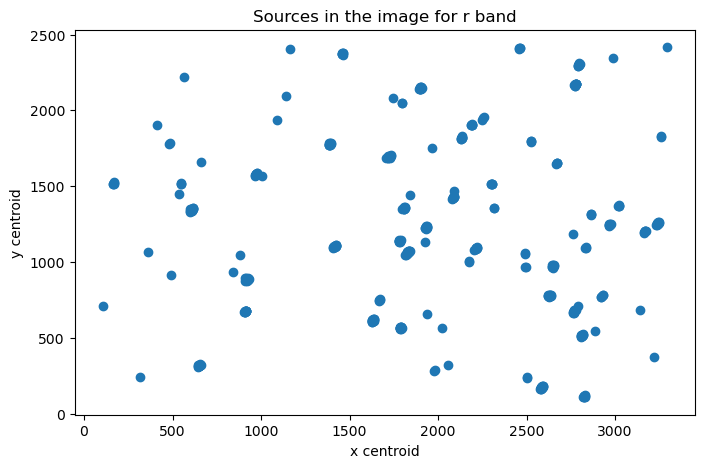

In [292]:
sources_r = op.Extract.detect_source(background_sub_r, std_r, 5.0)
plt.figure(figsize = (8,5))
plt.scatter(sources_r['xcentroid'], sources_r['ycentroid'])
plt.xlabel('x centroid')
plt.ylabel('y centroid')
plt.title("Sources in the image for r band")
plt.savefig("sources_r.png", format = 'png')
plt.show()

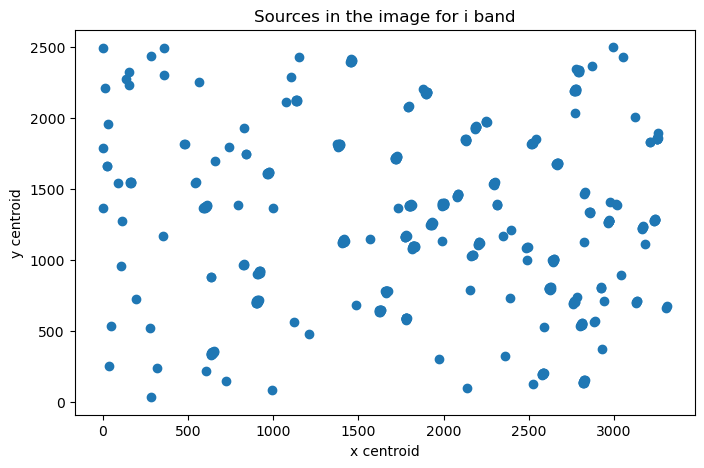

In [294]:
sources_i = op.Extract.detect_source(background_sub_i, std_i, 5.0)
plt.figure(figsize = (8,5))
plt.scatter(sources_i['xcentroid'], sources_i['ycentroid'])
plt.xlabel('x centroid')
plt.ylabel('y centroid')
plt.title("Sources in the image for i band")
plt.savefig("sources_i.png", format = 'png')
plt.show()

In [233]:
source_flux_g = op.Extract.estimate_source_fluxes(sources_g,background_sub_g)
source_flux_g

,id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag,aperture_sum
0,1,2947.162008,89.141332,0.713788,-0.023288,0.117971,25,2563.938690,61736.690709,-12.743561,-0.342888,125148.085042
1,2,2933.837582,96.019589,0.493277,-0.168285,-0.127402,25,8128.859421,190578.733710,-13.905446,-2.310937,364903.911147
2,3,2938.085220,97.391606,0.488106,0.317904,0.499257,25,10452.472027,244916.500901,-14.207334,-2.532760,481874.189247
3,4,2939.272556,98.126684,0.554826,0.451320,0.987194,25,10700.274309,252857.321354,-14.219380,-2.365677,487249.972786
4,5,2940.409610,101.515648,0.263144,0.074309,0.249757,25,9944.982898,239317.155036,-14.200521,-2.410600,478859.726814
...,...,...,...,...,...,...,...,...,...,...,...,...
458,459,2574.122842,2387.415551,0.388188,-0.034713,0.038979,25,719.938703,16647.102072,-11.284585,-0.350317,32646.309918
459,460,2571.573526,2387.597898,0.689966,0.052647,-0.695305,25,808.594484,18146.847331,-11.401918,-0.279344,36372.004934
460,461,2572.003279,2387.871524,0.251796,-0.043919,0.367131,25,743.287346,17286.299075,-11.386542,-0.531018,35860.522745
461,462,3053.592220,2432.961507,0.264214,0.068983,0.339600,25,15.527002,-208.059462,NaN,-0.420678,-144.128717


In [235]:
source_flux_r = op.Extract.estimate_source_fluxes(sources_r,background_sub_r)
source_flux_r

,id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag,aperture_sum
0,1,2823.582678,109.159217,0.564659,0.230422,0.917186,25,5249.466617,122694.138344,-13.531451,-1.948908,258571.439300
1,2,2817.815562,110.093946,0.268580,0.719320,-0.453113,25,3773.942632,91956.347410,-13.127709,-1.131672,178272.125625
2,3,2830.140508,112.131069,0.219020,-0.214295,0.260302,25,5563.555491,137107.002738,-13.590490,-1.125500,273021.029102
3,4,2824.821951,113.078446,0.495952,-0.012913,0.378483,25,7857.054488,182457.204789,-13.939420,-2.449689,376502.580693
4,5,2825.907445,116.117075,0.353194,-0.183766,0.116649,25,8938.097120,211435.328727,-14.081190,-2.518026,429018.329533
...,...,...,...,...,...,...,...,...,...,...,...,...
448,449,2459.980566,2406.730558,0.365968,-0.267155,-0.146002,25,571.302497,13460.611720,-11.073419,-0.133863,26876.178763
449,450,2460.642307,2408.786273,0.476380,0.472409,-0.172023,25,524.859558,11822.118154,-11.001272,-0.166785,25148.318655
450,451,2460.665570,2410.901951,0.487729,0.124413,-0.108467,25,506.440596,11633.212185,-10.891755,-0.053743,22735.376951
451,452,2459.910741,2412.835192,0.396371,-0.003361,0.226151,25,419.918980,9609.290127,-10.710644,-0.054210,19242.331479


In [236]:
source_flux_i = op.Extract.estimate_source_fluxes(sources_i,background_sub_i)
source_flux_i

,id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag,aperture_sum
0,1,282.220946,35.092975,0.364964,-0.153574,-0.594924,25,13.473538,-108.645937,NaN,-0.005630,-319.544278
1,2,994.992822,83.625713,0.298711,-0.088442,-0.699071,25,12.535157,-77.976784,NaN,-0.023043,-98.943538
2,3,2137.432095,101.837009,0.593665,0.489734,0.583848,25,25.750832,-104.818030,NaN,-0.021924,-83.187895
3,4,2524.761125,124.900422,0.755706,0.247419,-0.124999,25,43.304439,83.576338,-4.619215,-0.035398,70.418346
4,5,2815.860803,137.148086,0.368904,0.273317,0.065223,25,2721.304257,63798.197430,-12.732274,-1.810747,123853.837367
...,...,...,...,...,...,...,...,...,...,...,...,...
486,487,1152.557133,2433.780821,0.675252,0.129776,0.624232,25,194.010141,3977.651735,-9.814603,-0.024081,8430.261532
487,488,283.928714,2441.337321,0.443642,0.819092,0.405171,25,28.983962,27.901301,-4.204652,-0.043660,48.068518
488,489,4.725091,2491.366813,0.535435,0.108747,0.333431,25,28.776067,76.155480,-3.991017,-0.052312,39.482706
489,490,358.794122,2491.382841,0.335466,0.006689,-0.725286,25,16.026093,-89.390499,NaN,-0.139923,-57.842959


In [241]:
noise_g = op.Extract.get_flux_uncertainties(source_flux_g, background_g)
noise_g

,id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag,aperture_sum,flux_err
0,1,2947.162008,89.141332,0.713788,-0.023288,0.117971,25,2563.938690,61736.690709,-12.743561,-0.342888,125148.085042,367.953156
1,2,2933.837582,96.019589,0.493277,-0.168285,-0.127402,25,8128.859421,190578.733710,-13.905446,-2.310937,364903.911147,612.491103
2,3,2938.085220,97.391606,0.488106,0.317904,0.499257,25,10452.472027,244916.500901,-14.207334,-2.532760,481874.189247,701.509536
3,4,2939.272556,98.126684,0.554826,0.451320,0.987194,25,10700.274309,252857.321354,-14.219380,-2.365677,487249.972786,705.330711
4,5,2940.409610,101.515648,0.263144,0.074309,0.249757,25,9944.982898,239317.155036,-14.200521,-2.410600,478859.726814,699.357681
...,...,...,...,...,...,...,...,...,...,...,...,...,...
458,459,2574.122842,2387.415551,0.388188,-0.034713,0.038979,25,719.938703,16647.102072,-11.284585,-0.350317,32646.309918,207.093577
459,460,2571.573526,2387.597898,0.689966,0.052647,-0.695305,25,808.594484,18146.847331,-11.401918,-0.279344,36372.004934,215.901470
460,461,2572.003279,2387.871524,0.251796,-0.043919,0.367131,25,743.287346,17286.299075,-11.386542,-0.531018,35860.522745,214.713675
461,462,3053.592220,2432.961507,0.264214,0.068983,0.339600,25,15.527002,-208.059462,NaN,-0.420678,-144.128717,100.485377


In [243]:
noise_r = op.Extract.get_flux_uncertainties(source_flux_r, background_r)
noise_r

,id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag,aperture_sum,flux_err
0,1,2823.582678,109.159217,0.564659,0.230422,0.917186,25,5249.466617,122694.138344,-13.531451,-1.948908,258571.439300,518.169106
1,2,2817.815562,110.093946,0.268580,0.719320,-0.453113,25,3773.942632,91956.347410,-13.127709,-1.131672,178272.125625,433.820134
2,3,2830.140508,112.131069,0.219020,-0.214295,0.260302,25,5563.555491,137107.002738,-13.590490,-1.125500,273021.029102,531.929330
3,4,2824.821951,113.078446,0.495952,-0.012913,0.378483,25,7857.054488,182457.204789,-13.939420,-2.449689,376502.580693,621.635233
4,5,2825.907445,116.117075,0.353194,-0.183766,0.116649,25,8938.097120,211435.328727,-14.081190,-2.518026,429018.329533,662.530084
...,...,...,...,...,...,...,...,...,...,...,...,...,...
448,449,2459.980566,2406.730558,0.365968,-0.267155,-0.146002,25,571.302497,13460.611720,-11.073419,-0.133863,26876.178763,191.843586
449,450,2460.642307,2408.786273,0.476380,0.472409,-0.172023,25,524.859558,11822.118154,-11.001272,-0.166785,25148.318655,187.286149
450,451,2460.665570,2410.901951,0.487729,0.124413,-0.108467,25,506.440596,11633.212185,-10.891755,-0.053743,22735.376951,180.729521
451,452,2459.910741,2412.835192,0.396371,-0.003361,0.226151,25,419.918980,9609.290127,-10.710644,-0.054210,19242.331479,170.792606


In [245]:
noise_i = op.Extract.get_flux_uncertainties(source_flux_i, background_i)
noise_i

,id,xcentroid,ycentroid,sharpness,roundness1,roundness2,npix,peak,flux,mag,daofind_mag,aperture_sum,flux_err
0,1,282.220946,35.092975,0.364964,-0.153574,-0.594924,25,13.473538,-108.645937,NaN,-0.005630,-319.544278,71.075450
1,2,994.992822,83.625713,0.298711,-0.088442,-0.699071,25,12.535157,-77.976784,NaN,-0.023043,-98.943538,72.610745
2,3,2137.432095,101.837009,0.593665,0.489734,0.583848,25,25.750832,-104.818030,NaN,-0.021924,-83.187895,72.719158
3,4,2524.761125,124.900422,0.755706,0.247419,-0.124999,25,43.304439,83.576338,-4.619215,-0.035398,70.418346,73.767759
4,5,2815.860803,137.148086,0.368904,0.273317,0.065223,25,2721.304257,63798.197430,-12.732274,-1.810747,123853.837367,359.478930
...,...,...,...,...,...,...,...,...,...,...,...,...,...
486,487,1152.557133,2433.780821,0.675252,0.129776,0.624232,25,194.010141,3977.651735,-9.814603,-0.024081,8430.261532,117.479894
487,488,283.928714,2441.337321,0.443642,0.819092,0.405171,25,28.983962,27.901301,-4.204652,-0.043660,48.068518,73.616115
488,489,4.725091,2491.366813,0.535435,0.108747,0.333431,25,28.776067,76.155480,-3.991017,-0.052312,39.482706,73.557777
489,490,358.794122,2491.382841,0.335466,0.006689,-0.725286,25,16.026093,-89.390499,NaN,-0.139923,-57.842959,72.893216


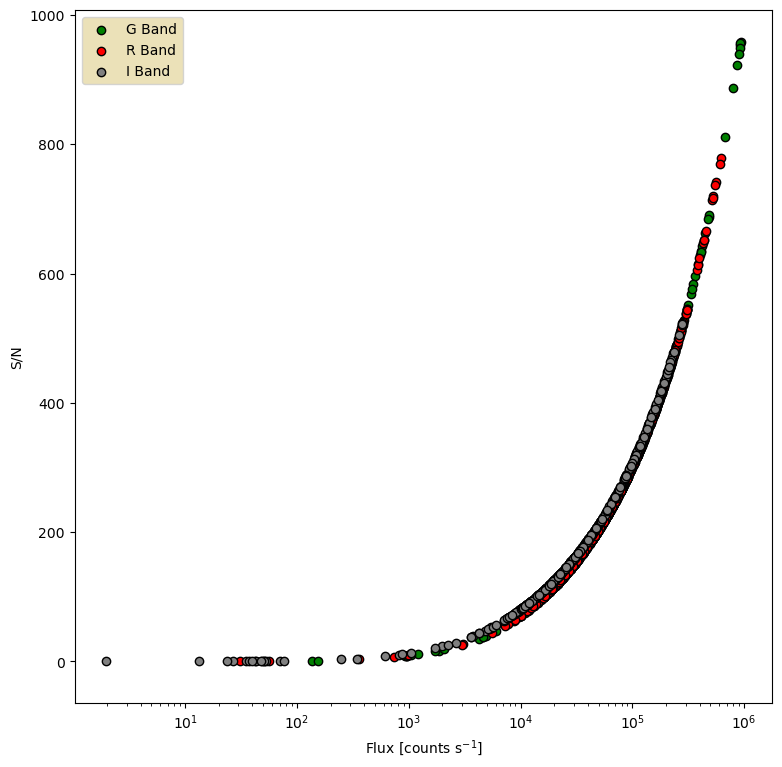

In [247]:
fig, ax = plt.subplots(figsize=(9,9))
ax.scatter(noise_g['aperture_sum'],noise_g['aperture_sum']/noise_g['flux_err'],c='green',edgecolor='k',label='G Band')
ax.scatter(noise_r['aperture_sum'],noise_r['aperture_sum']/noise_r['flux_err'],c='red',edgecolor='k',label='R Band')
ax.scatter(noise_i['aperture_sum'],noise_i['aperture_sum']/noise_i['flux_err'],c='grey',edgecolor='k',label='I Band')
ax.set_ylabel('S/N')
ax.set_xscale('log')
ax.legend(facecolor='xkcd:beige',loc='upper left')
ax.set_xlabel(r'Flux [counts s$^{-1}$]')
plt.savefig('flux_uncertainties.png', format = 'png')

In [248]:
noise_g = sources_g.query('aperture_sum > 0').sort_values('aperture_sum',ascending=False).reset_index(drop=True)
noise_r = sources_r.query('aperture_sum > 0').sort_values('aperture_sum',ascending=False).reset_index(drop=True)
noise_i = sources_i.query('aperture_sum > 0').sort_values('aperture_sum',ascending=False).reset_index(drop=True)

In [251]:
from astroquery.astrometry_net import AstrometryNet
AstrometryNet.api_key = 'qvqugvasnorsubbd'

ast = AstrometryNet()

wcs_header_g = ast.solve_from_source_list(x=noise_g['xcentroid'], y=noise_g['ycentroid'],
                                        image_width=background_sub_g.shape[1], image_height=background_sub_g.shape[0],
                                        solve_timeout=1000,scale_units='arcsecperpix', scale_lower=0.25, scale_upper=0.3)

wcs_header_r = ast.solve_from_source_list(x=noise_r['xcentroid'], y=noise_r['ycentroid'],
                                        image_width=background_sub_r.shape[1], image_height=background_sub_r.shape[0],
                                        solve_timeout=1000,scale_units='arcsecperpix', scale_lower=0.25, scale_upper=0.3)

wcs_header_i = ast.solve_from_source_list(x=noise_i['xcentroid'], y=noise_i['ycentroid'],
                                        image_width=background_sub_i.shape[1], image_height=background_sub_i.shape[0],
                                        solve_timeout=1000,scale_units='arcsecperpix', scale_lower=0.25, scale_upper=0.3)

w_g = WCS(wcs_header_g)
w_r = WCS(wcs_header_r)
w_i= WCS(wcs_header_i)

Solving............Solving............Solving..........

In [252]:
noise_g = noise_g.assign(ra= lambda x: w_g.pixel_to_world(x['xcentroid'],x['ycentroid']).ra.degree,
                             dec= lambda x: w_g.pixel_to_world(x['xcentroid'],x['ycentroid']).dec.degree)
noise_r = noise_r.assign(ra= lambda x: w_r.pixel_to_world(x['xcentroid'],x['ycentroid']).ra.degree,
                             dec= lambda x: w_r.pixel_to_world(x['xcentroid'],x['ycentroid']).dec.degree)
noise_i = noise_i.assign(ra= lambda x: w_i.pixel_to_world(x['xcentroid'],x['ycentroid']).ra.degree, 
                             dec= lambda x: w_i.pixel_to_world(x['xcentroid'],x['ycentroid']).dec.degree)

In [253]:
max_radius = 2. / 3600

dist, ind = crossmatch_angular(noise_g[['ra','dec']].values, noise_r[['ra','dec']].values, max_radius)
match = ~np.isinf(dist)

merged_sources = pd.concat([noise_g[match].reset_index(drop=True)[['ra','dec','mag','aperture_sum','flux_err']]
                            .rename(columns={'mag':'gmag','aperture_sum':'gflux','flux_err':'gflux_err'}), 
                            noise_r.iloc[ind[match]].reset_index(drop=True)[['mag','aperture_sum','flux_err']]
                            .rename(columns={'mag':'rmag','aperture_sum':'rflux','flux_err':'rflux_err'})], axis=1)

dist1, ind1 = crossmatch_angular(noise_i[['ra','dec']].values, merged_sources[['ra','dec']].values, max_radius)
match1 = ~np.isinf(dist1)

merged_sources = pd.concat([ merged_sources.iloc[ind1[match1]].reset_index(drop=True), noise_i[match1].reset_index(drop=True)[['mag','aperture_sum','flux_err']]
.rename(columns={'mag':'imag','aperture_sum':'iflux','flux_err':'iflux_err'})],axis=1)

In [254]:
merged_sources.to_csv('merged_sources.csv',index=False)

In [255]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from reproject import reproject_interp
from skimage import exposure

g_data = background_sub_g
r_data = background_sub_r
i_data = background_sub_i

ref_wcs = w_g
ref_shape = g_data.shape

r_aligned, _ = reproject_interp((r_data, w_r), ref_wcs, shape_out=ref_shape)
i_aligned, _ = reproject_interp((i_data, w_i), ref_wcs, shape_out=ref_shape)

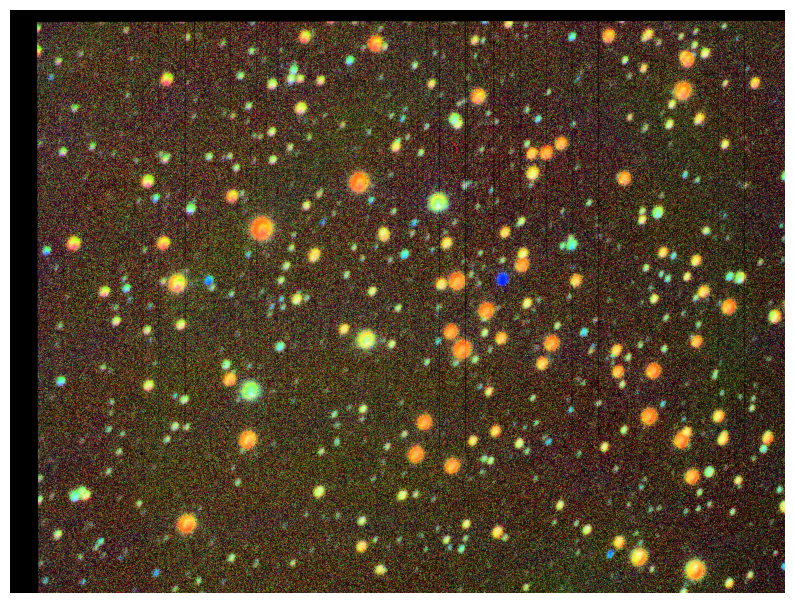

In [272]:
from astropy.visualization import make_lupton_rgb
from scipy.ndimage import gaussian_filter

g_smooth = gaussian_filter(g_data, sigma=.5)
r_smooth = gaussian_filter(r_aligned, sigma=.5)
i_smooth = gaussian_filter(i_aligned, sigma=.5)

rgb_image = make_lupton_rgb(g_smooth, r_smooth, i_smooth, Q=10, stretch=0.5, minimum=0)

# Display the image
fig,ax = plt.subplots(figsize=(10,10))
ax.imshow(rgb_image, origin='lower')
ax.axis('off')
plt.savefig('ngc1528.png', format = 'png')
plt.show()

#fig.savefig('ngc1528.pdf')
# fits.PrimaryHDU(data=rgb_image,header=wcs_header_g).writeto('m56_5.fits',overwrite=False)

In [257]:
import numpy as np
from astroquery.vizier import Vizier
from astropy.coordinates import SkyCoord
from astropy import units as u

ngc1528_center = SkyCoord(ra=65.71, dec=51.21,unit='deg')
search_radius = 2 * u.deg

Vizier.ROW_LIMIT = -1
catalog = Vizier.query_region(ngc1528_center, radius=search_radius, catalog="II/349/ps1")[0]

catalog_stars = catalog[['RAJ2000', 'DEJ2000', 'gmag', 'rmag', 'imag']]
catalog_coords = SkyCoord(ra=catalog_stars['RAJ2000'], dec=catalog_stars['DEJ2000'],unit='deg')

observed_coords = SkyCoord(ra=merged_sources['ra'], dec=merged_sources['dec'],unit='deg')

idx, d2d, _ = observed_coords.match_to_catalog_sky(catalog_coords)
matched = d2d < 1 * u.arcsec

g_mag_cat = catalog_stars['gmag'][idx[matched]]
r_mag_cat = catalog_stars['rmag'][idx[matched]]
i_mag_cat = catalog_stars['imag'][idx[matched]]

g_mag_inst = merged_sources['gmag'][matched]
r_mag_inst = merged_sources['rmag'][matched]
i_mag_inst = merged_sources['imag'][matched]

g_zp = np.array(g_mag_cat) - np.array(g_mag_inst)
r_zp = np.array(r_mag_cat) - np.array(r_mag_inst)
i_zp = np.array(i_mag_cat) - np.array(i_mag_inst)

zp_g = np.median(g_zp[np.isfinite(g_zp)])
zp_r = np.median(r_zp[np.isfinite(r_zp)])
zp_i = np.median(i_zp[np.isfinite(i_zp)])

print(f"Zero Point for g-band: {zp_g}")
print(f"Zero Point for r-band: {zp_r}")
print(f"Zero Point for i-band: {zp_i}")

merged_sources['gmag'] += zp_g
merged_sources['rmag'] += zp_r
merged_sources['imag'] += zp_i

Zero Point for g-band: 23.817652348729098
Zero Point for r-band: 23.420702182105735
Zero Point for i-band: 22.59451412824947


In [258]:
from uwastro465isos import isochrones
iso = isochrones.Isochrone_Sloan()

In [259]:
imag, g_i = merged_sources['gmag'] - merged_sources['imag'], merged_sources['imag']

models_with_residuals = []

for age in iso.get_list_of_ages():
    for z in iso.get_list_of_metallicities():
        model = iso.select_isochrone(age, z)
        model['g_i'] = model['gmag'] - model['imag']
        model = model.loc[model.label == 3]
        
        residuals = []
        for i_obs, g_i_obs in zip(imag, g_i):
            dist = np.sqrt((model['imag'] - i_obs)**2 + (model['g_i'] - g_i_obs)**2)
            closest_distance = np.min(dist)  
            residuals.append(closest_distance ** 2)

        residual_sum = np.sum(residuals)  

        models_with_residuals.append({'age': age, 'metallicity': z, 'residual_sum': residual_sum})

models_with_residuals.sort(key=lambda x: x['residual_sum'])

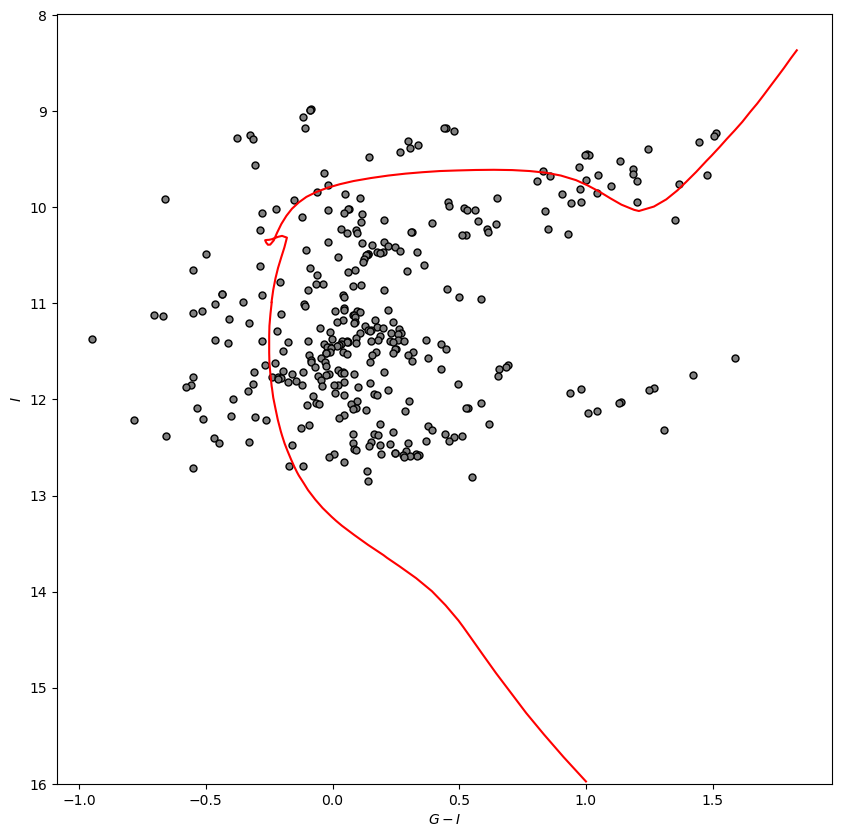

In [274]:
model = iso.select_isochrone(8.5, 0)
model = model.loc[(model.label < 4) & (model.label > 0)]
model['g_i'] = model['gmag'] - model['imag'] + 0.3
model['imag'] -= (-5 - 5*np.log10(1000/65))

fig, ax = plt.subplots(figsize=(10,10))

ax.scatter((merged_sources['gmag']-merged_sources['imag']),merged_sources['imag'],edgecolor='k',s=25,color='grey')
ax.plot(model['g_i'],model['imag'],color='r')
ax.invert_yaxis()
ax.set_xlabel(r'$G - I$')
ax.set_ylabel(r'$I$')

ax.set_ylim(bottom=16)
plt.savefig('cmd.png', format = 'png')